<H2>STUDENT NAME: ABIOLA PEACE EMMANUEL</H2>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

<h1>Task 1</h1>

<h2>Data Cleaning</h2>
<h3>The census dataset will be imported and inspected to understand its structure, identify column types, and check for irregularities. This will provide the foundation for further analysis.</h3>

In [3]:
# Load dataset
file_path = "T2_A24_census7.xlsx"   # change path if needed
data = pd.read_excel(file_path, sheet_name="Sheet1")

# Make a copy for cleaning
cleaned = data.copy()

# ---- 1. Standardize column names ----
cleaned.columns = cleaned.columns.str.strip().str.lower().str.replace(" ", "_")

# ---- 2. Handle missing values ----
cleaned["surname"] = cleaned["surname"].fillna("Unknown")
cleaned["relationship_to_head_of_house"] = cleaned["relationship_to_head_of_house"].fillna("Unknown")
cleaned["marital_status"] = cleaned["marital_status"].fillna("Unknown")
cleaned["infirmity"] = cleaned["infirmity"].fillna("None")
cleaned["religion"] = cleaned["religion"].fillna("Unknown")

# ---- 3. Standardize categorical text ----
def standardize_text(series):
    return series.astype(str).str.strip().str.title()

cleaned["first_name"] = standardize_text(cleaned["first_name"])
cleaned["surname"] = standardize_text(cleaned["surname"])
cleaned["street"] = standardize_text(cleaned["street"])
cleaned["relationship_to_head_of_house"] = standardize_text(cleaned["relationship_to_head_of_house"])
cleaned["marital_status"] = standardize_text(cleaned["marital_status"])
cleaned["gender"] = cleaned["gender"].str.strip().str.capitalize()
cleaned["occupation"] = cleaned["occupation"].str.strip()
cleaned["religion"] = standardize_text(cleaned["religion"])

# ---- 4. Fix gender values ----
gender_map = {
    "M": "Male", "Male": "Male",
    "F": "Female", "Female": "Female",
    "Unknown": "Unknown", "U": "Unknown",
    "Other": "Other", "O": "Other"
}
cleaned["gender"] = cleaned["gender"].map(gender_map).fillna("Unknown")

# ---- 5. Fix marital status inconsistencies ----
marital_map = {
    "Married": "Married",
    "Single": "Single",
    "Widowed": "Widowed",
    "Divorced": "Divorced",
    "Unknown": "Unknown"
}
cleaned["marital_status"] = cleaned["marital_status"].map(marital_map).fillna("Unknown")

# ---- 6. Relationship standardization ----
relationship_map = {
    "Head": "Head",
    "Wife": "Spouse",
    "Husband": "Spouse",
    "Son": "Child",
    "Daughter": "Child",
    "Unknown": "Unknown"
}
cleaned["relationship_to_head_of_house"] = cleaned["relationship_to_head_of_house"].map(relationship_map).fillna("Other")

# ---- 7. Validate Age ----
cleaned.loc[(cleaned["age"] < 0) | (cleaned["age"] > 120), "age"] = np.nan
median_age = cleaned["age"].median()
cleaned["age"] = cleaned["age"].fillna(median_age).astype(int)

# ---- 8. Drop duplicates ----
cleaned = cleaned.drop_duplicates()

# ---- 9. Save cleaned dataset ----
output_path = "T2_A24_census7_cleaned.xlsx"
cleaned.to_excel(output_path, index=False)

print(f"✅ Cleaning complete! File saved as: {output_path}")


✅ Cleaning complete! File saved as: T2_A24_census7_cleaned.xlsx


In [4]:
#Loading in the dataset
census_df = pd.read_excel("T2_A24_census7_cleaned.xlsx")
census_df.columns = census_df.columns.str.strip().str.lower().str.replace(" ", "_")
census_df

,house_number,street,first_name,surname,age,relationship_to_head_of_house,marital_status,gender,occupation,infirmity,religion
0,1,Scott Mission,Martin,Thomas,78,Head,Married,Male,Retired Environmental consultant,NaN,Christian
1,1,Scott Mission,Molly,Thomas,74,Spouse,Married,Female,"Retired Teacher, adult education",NaN,Christian
2,2,Scott Mission,Julia,Finch,41,Head,Married,Female,Unemployed,NaN,No Religion
3,2,Scott Mission,Terence,Finch,44,Spouse,Married,Male,"Designer, television/film set",NaN,No Religion
4,2,Scott Mission,Sara,Finch,16,Child,Unknown,Female,Student,NaN,No Religion
...,...,...,...,...,...,...,...,...,...,...,...
7621,1,Wheeler Rocks,Abbie,Collins,52,Head,Married,Female,Legal executive,NaN,Christian
7622,1,Wheeler Rocks,Howard,Unknown,54,Spouse,Married,Male,Higher education lecturer,NaN,Christian
7623,1,Wheeler Rocks,Kirsty,Collins-Houghton,34,Child,Single,Female,"Designer, blown glass/stained glass",NaN,No Religion
7624,1,Wheeler Rocks,Mandy,Collins-Houghton,32,Child,Single,Female,Armed forces operational officer,NaN,Christian


In [5]:
# --- Religion Mapping ---
religion_map = {
    "Christian": "Christianity",
    "Church Of England": "Christianity",
    "Muslim": "Islam",
    "Athiest": "Atheist",
    "No Religion": "None",
    "Dark Brotherhood": "Unknown",
    "The Templars": "Unknown",
    "Asia": "Unknown"
}

census_df["religion"] = census_df["religion"].replace(religion_map)

# Standardize capitalization
census_df["religion"] = census_df["religion"].str.title()

# --- Occupation Simplification ---
def simplify_occupation(occ):
    if pd.isna(occ) or occ.strip() == "" or occ.lower() == "unknown":
        return "Unknown"
    occ = occ.lower()
    if "retired" in occ:
        return "Retired"
    elif "teacher" in occ:
        return "Teacher"
    elif "engineer" in occ:
        return "Engineer"
    elif "student" in occ:
        return "Student"
    elif "Trader" in occ:
        return "Trader"
    elif "unemployed" in occ:
        return "Unemployed"
    elif any(word in occ for word in ["doctor", "nurse", "health", "medical"]):
        return "Healthcare"
    elif any(word in occ for word in ["armed forces", "military", "soldier", "navy", "air force", "logistics", "operational officer", "training and education officer", "defense", "army",
    "forces", "troop", "combat", "service"]):
        return "Armed Forces"
    elif any(word in occ for word in ["child", "infant", "toddler", "minor", "baby", "kid", "young"]):
        return "Child"
    elif any(word in occ for word in ["admin", "secretary", "clerk", "assistant", "receptionist"]):
        return "Administrative"
    elif any(word in occ for word in ["sales", "retail", "cashier", "store", "shop"]):
        return "Sales"
    elif any(word in occ for word in ["finance", "accountant", "bank", "auditor", "bookkeeper"]):
        return "Finance"
    elif any(word in occ for word in ["construction", "builder", "carpenter", "plumber", "electrician"]):
        return "Construction"
    elif any(word in occ for word in ["tech", "developer", "programmer", "software", "it", "data"]):
        return "Technology"
    elif any(word in occ for word in ["driver", "transport", "delivery", "chauffeur", "truck"]):
        return "Transport"
    elif any(word in occ for word in ["lawyer", "attorney", "paralegal", "legal advisor", "solicitor", "barrister"]): 
        return "Legal"
    elif any(word in occ for word in ["manager", "executive", "director", "supervisor"]): 
        return "Management"
    elif any(word in occ for word in ["police", "firefighter", "security", "law enforcement"]): 
        return "Public Safety"
    elif any(word in occ for word in ["artist", "musician", "painter", "performer", "actor", "singer", "event planner"]): 
        return "Creative Arts"
    elif any(word in occ for word in ["chef", "cook", "kitchen", "catering"]): 
        return "Food Services"
    else:
        return "Other"

census_df["occupation"] = census_df["occupation"].apply(simplify_occupation)

In [6]:
# Check cleaned religion categories
print("Unique values in 'religion':")
print(census_df["religion"].value_counts())

# Check cleaned occupation categories
print("\nUnique values in 'occupation':")
print(census_df["occupation"].value_counts())

Unique values in 'religion':
religion
Christianity    3245
None            3167
Unknown         1000
Islam            108
Hindu             72
Sikh              27
Humanist           4
Bahai              2
Atheist            1
Name: count, dtype: int64

Unique values in 'occupation':
occupation
Student           2010
Other             1994
Retired            668
Technology         575
Unemployed         505
Child              462
Engineer           366
Management         315
Healthcare         186
Administrative     132
Teacher             98
Sales               88
Armed Forces        79
Finance             58
Creative Arts       37
Legal               22
Public Safety       17
Transport           14
Name: count, dtype: int64


<h1>Task 2</h1>

<h2>Data Analysis and Justification</h2>

<h2>🔹 Step 1: Age Distribution</h2>
<h3>In this section we will be analysing the Age Distribution visually</h3>

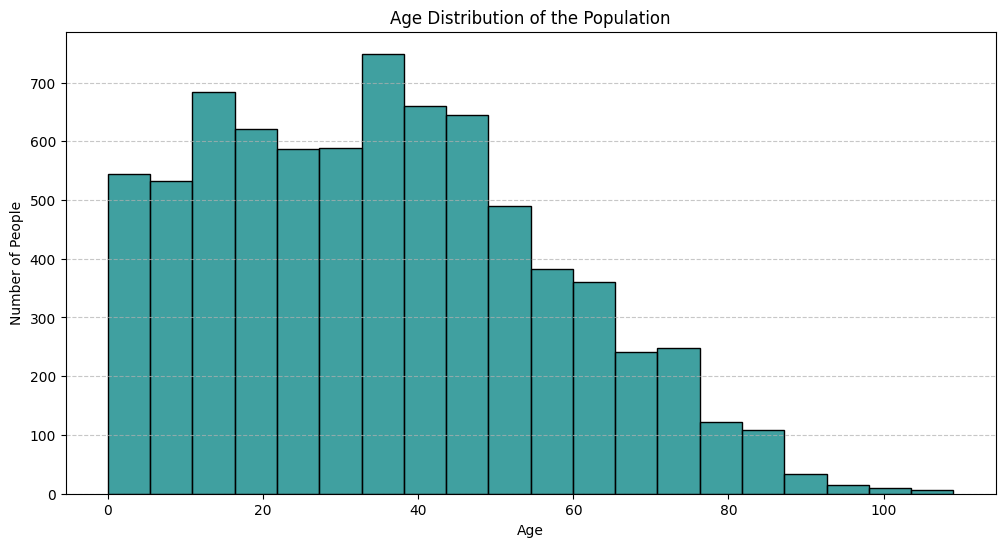

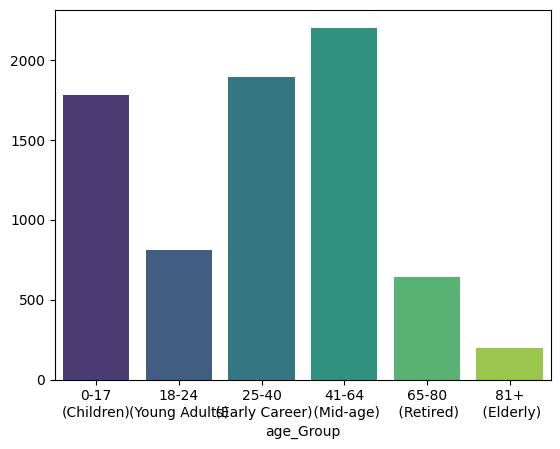

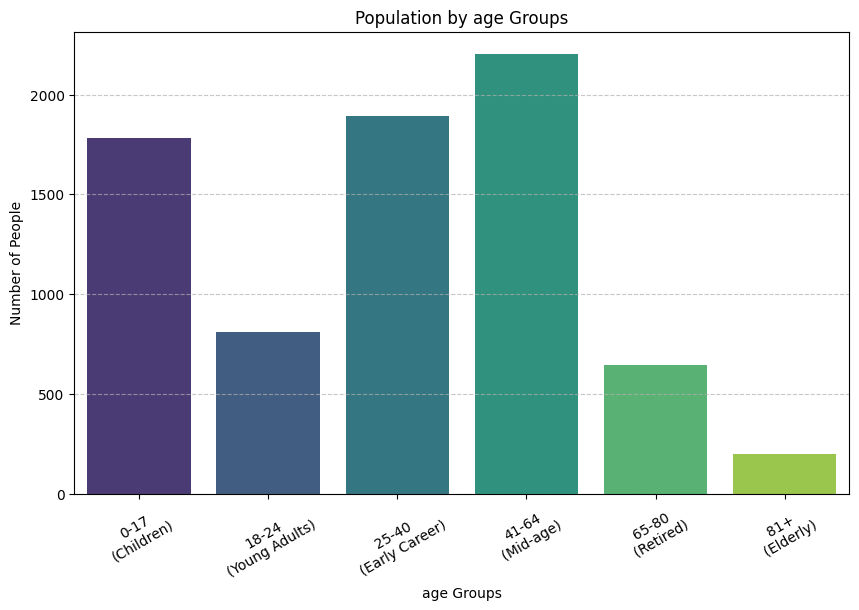

Population by age Groups:
age_Group
0-17\n(Children)          1784
18-24\n(Young Adults)      812
25-40\n (Early Career)    1894
41-64\n (Mid-age)         2204
65-80\n (Retired)          645
81+\n (Elderly)            199
Name: count, dtype: int64


In [7]:
# --- Step 1: Age Distribution Analysis ---

# Plot histogram of ages
plt.figure(figsize=(12,6))
sns.histplot(census_df['age'], bins=20, kde=False, color="teal")
plt.title("Age Distribution of the Population")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


# --- Group population by age bands ---
age_bins = [0, 17, 24, 40, 64, 80, 120]
age_labels = ["0-17\n(Children)", "18-24\n(Young Adults)", 
              "25-40\n (Early Career)", "41-64\n (Mid-age)", 
              "65-80\n (Retired)", "81+\n (Elderly)"]

census_df["age_Group"] = pd.cut(census_df["age"], bins=age_bins, labels=age_labels, right=True)

age_group_counts = census_df["age_Group"].value_counts().sort_index()


sns.barplot(
    x=age_group_counts.index, 
    y=age_group_counts.values, 
    hue=age_group_counts.index,   # treat each bar as a separate hue
    palette="viridis", 
    legend=False                  # disable the legend (since it's redundant here)
)

# Plot age group distribution
plt.figure(figsize=(10,6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, hue=age_group_counts.index, palette="viridis", legend=False)
plt.title("Population by age Groups")
plt.ylabel("Number of People")
plt.xlabel("age Groups")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# Display counts for decision making
print("Population by age Groups:")
print(age_group_counts)

<h2>🔹 Step 2: Occupancy Levels</h2>
<h3>In this section we will get all the information on the occupants and also provide the info visusally</h3>

Average household size: 2.79
Max occupancy in a dwelling: 19
Min occupancy in a dwelling: 1


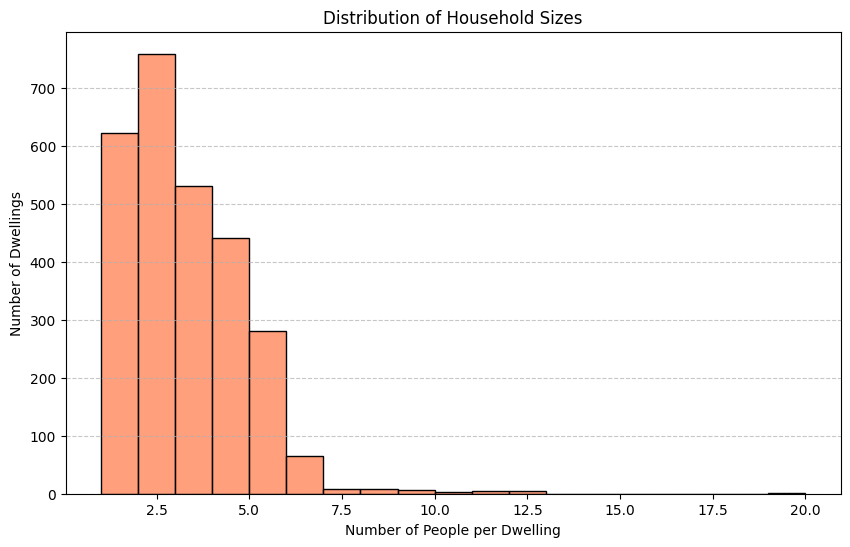

In [8]:
# Group by unique dwelling
census_df["dwelling"] = census_df["house_number"].astype(str) + " " + census_df["street"]
occupancy = census_df.groupby("dwelling").size()

# Summary stats
average_occupancy = occupancy.mean()
max_occupancy = occupancy.max()
min_occupancy = occupancy.min()

print(f"Average household size: {average_occupancy:.2f}")
print(f"Max occupancy in a dwelling: {max_occupancy}")
print(f"Min occupancy in a dwelling: {min_occupancy}")

# Visualise occupancy distribution
plt.figure(figsize=(10,6))
sns.histplot(occupancy, bins=range(1, occupancy.max()+2), color="coral", kde=False)
plt.title("Distribution of Household Sizes")
plt.xlabel("Number of People per Dwelling")
plt.ylabel("Number of Dwellings")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

<h2>🔹 Step 3: Employment Status</h2>
<h3>This section we will check how many people are unemployed, and under which age group they fall and visually represent it.</h3>

Total unemployed individuals: 505
Unemployment by Age Group:
age_Group
0-17\n(Children)            0
18-24\n(Young Adults)      18
25-40\n (Early Career)    206
41-64\n (Mid-age)         234
65-80\n (Retired)          43
81+\n (Elderly)             4
Name: count, dtype: int64


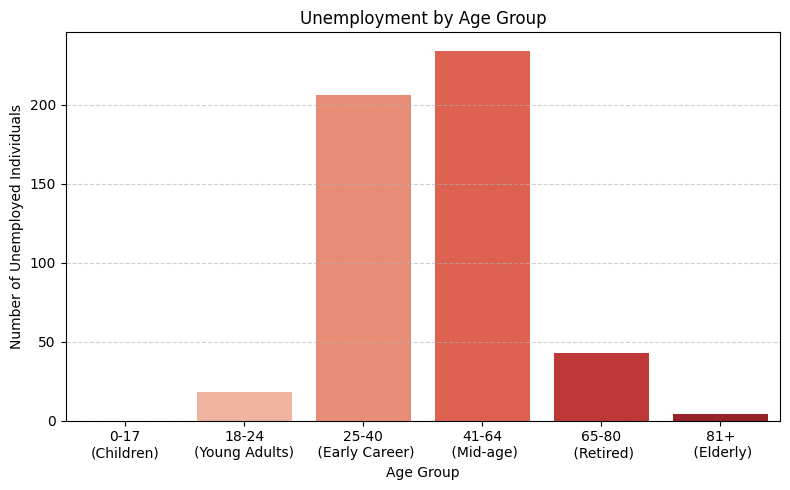

In [9]:
# Normalize occupation column
census_df["occupation_clean"] = census_df["occupation"].str.strip().str.lower()

# Flag unemployed
unemployed_mask = census_df["occupation_clean"].isna() | (census_df["occupation_clean"] == "unemployed")
unemployed_df = census_df[unemployed_mask]

print(f"Total unemployed individuals: {unemployed_df.shape[0]}")

# Unemployment by age Group
unemployment_by_age = unemployed_df["age_Group"].value_counts().sort_index()
# Display results
print("Unemployment by Age Group:")
print(unemployment_by_age)

# Convert Series to DataFrame
unemployment_df = pd.DataFrame({
    "Age Group": unemployment_by_age.index,
    "Unemployed": unemployment_by_age.values
})

plt.figure(figsize=(8,5))
sns.barplot(data=unemployment_df, x="Age Group", y="Unemployed", hue="Age Group", palette="Reds", legend=False)
plt.title("Unemployment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Unemployed Individuals")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


<h2>🔹 Step 4: Religion Analysis</h2>
<h3>This section we will be counting the population based on their religion and also visually reprsent it.</h3>

Population by Religion:
religion
Christianity    3245
None            3167
Unknown         1000
Islam            108
Hindu             72
Sikh              27
Humanist           4
Bahai              2
Atheist            1
Name: count, dtype: int64


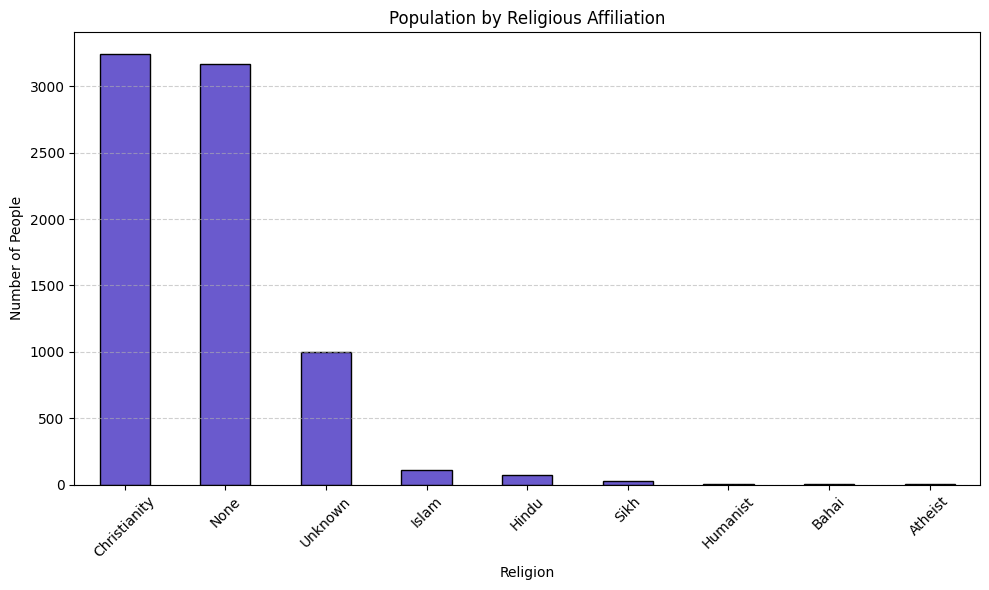

In [10]:
# Counting population by religion
religion_counts = census_df["religion"].value_counts().sort_values(ascending=False)
print("Population by Religion:")
print(religion_counts)

plt.figure(figsize=(10,6))
religion_counts.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Population by Religious Affiliation")
plt.xlabel("Religion")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


<h2>🔹 Step 5: Marital Status</h2>
<h3>This section we will be counting the population based on their marital status and also visually reprsent it.</h3>

Population by Marital Status:
marital_status
Single      2594
Married     2219
Unknown     1827
Divorced     679
Widowed      307
Name: count, dtype: int64


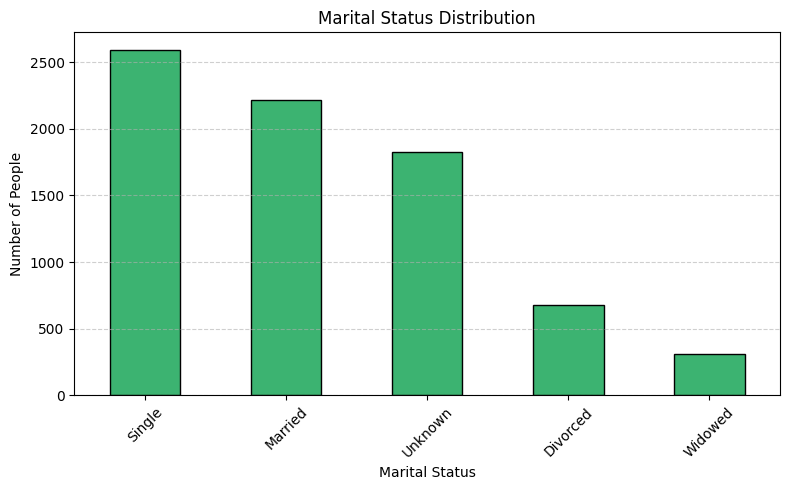

In [11]:
# Count population by marital status
marital_counts = census_df["marital_status"].value_counts().sort_values(ascending=False)
print("Population by Marital Status:")
print(marital_counts)

plt.figure(figsize=(8,5))
marital_counts.plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

<h2>🔹 Step 6: Commuters</h2>

In [12]:
# Identifying student commuting to university
student_commuters = census_df[census_df["occupation"].str.contains("student", case=False, na=False)]
num_students = len(student_commuters)
print(f"Estimated university-level students: {num_students}")

# Identify commuter type jobs 
commuter_jobs = ["Technology", "Finance", "Consultant", "Legal", "Marketing", "Engineer", "Accountant", "Architect", "Analyst"]
commuter_df = census_df[census_df["occupation"].str.contains('|'.join(commuter_jobs), case=False, na=False)]
num_commuters = len(commuter_df)
print(f"Estimated commuter-type professionals: {num_commuters}")

# Print total commuters 
total_commuters = num_students + num_commuters
percent_commuters = round((total_commuters / len(census_df)) * 100, 2)
print(f"Total estimated commuters: {total_commuters} ({percent_commuters}%)")

Estimated university-level students: 2010
Estimated commuter-type professionals: 1021
Total estimated commuters: 3031 (39.75%)


<h2>🔹 Step 7: Infirmities & Medical Needs</h2>

In [13]:
injury_keywords = ["injury", "disabled", "disability", "mobility", "blind", "deaf", "mental", "physical"]

# Flag entries with any keyword
census_df["has_infirmity"] = census_df["infirmity"].str.lower().apply(
    lambda x: any(k in x for k in injury_keywords) if pd.notnull(x) else False
)
num_infirm = census_df["has_infirmity"].sum()
print(f"Total individuals with infirmities: {num_infirm}")

# Count women of childbearing age 18-40
# Filter by gender and age
childbearing_women = census_df[
    (census_df["gender"].str.lower() == "female") &
    (census_df["age"].between(18, 40))
]
num_childbearing = childbearing_women.shape[0]
print(f"Women of childbearing age (18–40): {num_childbearing}")

Total individuals with infirmities: 72
Women of childbearing age (18–40): 1460


<h2>🔹 Step 8: Birth & Death Rates</h2>
<h3>This section will be Estimating deaths for the new births and elderly to enhance the analysis.</h3>

In [14]:
new_births = census_df[census_df["age"].between(0, 1)].shape[0]
print(f"Estimated new births (age 0, 1): {new_births}")

# Estimate Elderly deaths age 85+ with infirmities
elderly_with_infirmities = census_df[
    (census_df["age"] >= 85) &
    (census_df["has_infirmity"] == True)  # assuming this flag was created in Step 7
]
estimated_deaths = elderly_with_infirmities.shape[0]
print(f"Estimated elderly deaths (85+ with infirmities): {estimated_deaths}")

Estimated new births (age 0, 1): 172
Estimated elderly deaths (85+ with infirmities): 0


<h2>🔹 Step 9: Final Decision & Recommendations</h2>
<h3>Based on the analysis, recommendations were made regarding what should be built on the available land and what investment areas (e.g., education, employment, healthcare) should be prioritized. The decisions were justified with demographic evidence from the dataset.  </h3>

In [16]:
# --- Step 9: Final Decision & Recommendations ---

# 1. Summarize key statistics
age_groups_summary = census_df["age_Group"].value_counts(sort=False).sort_index()
employment_summary = census_df["occupation_clean"].value_counts(normalize=True) * 100
religion_summary = census_df["religion"].value_counts(normalize=True) * 100
infirmity_summary = census_df["has_infirmity"].value_counts(normalize=True) * 100

print("📊 Age Group Distribution:\n", age_groups_summary, "\n")
print("📊 Employment Distribution (%):\n", employment_summary.round(2), "\n")
print("📊 Religion Distribution (%):\n", religion_summary.round(2), "\n")
print("📊 Infirmity Distribution (%):\n", infirmity_summary.round(2), "\n")

# 2. Generate Recommendations based on data
recommendations = []

# Age-based facilities
if age_groups_summary.get("0-17 (Children)", 0) > age_groups_summary.sum() * 0.25:
    recommendations.append("➡ Invest in schooling and playgrounds (large child population).")

if (age_groups_summary.get("65-80 (Retired)", 0) + 
    age_groups_summary.get("81+ (Elderly)", 0)) > age_groups_summary.sum() * 0.20:
    recommendations.append("➡ Build old-age care facilities or medical centres (aging population).")

# Employment-based facilities
if employment_summary.get("Unemployed", 0) > 10:
    recommendations.append("➡ Invest in job creation programs and skill training (high unemployment).")

if employment_summary.get("Student", 0) > 10:
    recommendations.append("➡ Expand educational institutions (many students in population).")

# Religion-based facilities
top_religion = religion_summary.idxmax()
if religion_summary[top_religion] > 40:
    recommendations.append(f"➡ Build or expand a {top_religion} religious site (large religious community).")

# Infirmity-based facilities
if infirmity_summary.get(True, 0) > 5:
    recommendations.append("➡ Build medical centres and disability support services (notable infirmity cases).")

📊 Age Group Distribution:
 age_Group
0-17\n(Children)          1784
18-24\n(Young Adults)      812
25-40\n (Early Career)    1894
41-64\n (Mid-age)         2204
65-80\n (Retired)          645
81+\n (Elderly)            199
Name: count, dtype: int64 

📊 Employment Distribution (%):
 occupation_clean
student           26.36
other             26.15
retired            8.76
technology         7.54
unemployed         6.62
child              6.06
engineer           4.80
management         4.13
healthcare         2.44
administrative     1.73
teacher            1.29
sales              1.15
armed forces       1.04
finance            0.76
creative arts      0.49
legal              0.29
public safety      0.22
transport          0.18
Name: proportion, dtype: float64 

📊 Religion Distribution (%):
 religion
Christianity    42.55
None            41.53
Unknown         13.11
Islam            1.42
Hindu            0.94
Sikh             0.35
Humanist         0.05
Bahai            0.03
Atheist          0

In [15]:
# --- Step 9: Final Decision & Recommendations ---

# ✅ Ensure consistent categories
employment_summary = census_df["occupation_clean"].str.lower().value_counts(normalize=True) * 100
religion_summary = census_df["religion"].str.title().value_counts(normalize=True) * 100
infirmity_summary = census_df["has_infirmity"].value_counts(normalize=True) * 100
age_groups_summary = census_df["age_Group"].value_counts().sort_index()

def make_final_recommendations(age_counts, employment_props, religion_props, infirmity_props):
    recommendations = []

    # --- 1. Age-related needs ---
    if age_counts.get("0-17 (Children)", 0) > 1500:
        recommendations.append("Build or expand schools, training centres, and student facilities (large child/student population).")

    if age_counts.get("25-40 (Early Career)", 0) + age_counts.get("41-64 (Mid-age)", 0) > 3500:
        recommendations.append("Develop new housing projects for families (large mid-age and early-career groups).")

    if age_counts.get("65-80 (Retired)", 0) + age_counts.get("81+ (Elderly)", 0) > 700:
        recommendations.append("Plan for elderly care facilities (not urgent, but population is growing).")

    # --- 2. Employment-related needs ---
    if employment_props.get("student", 0) > 20:
        recommendations.append("Invest in higher education, skill development, and youth programs (many students).")

    if employment_props.get("unemployed", 0) > 5:
        recommendations.append("Create job opportunities and entrepreneurship programs (unemployment is moderate).")

    # --- 3. Religion & community ---
    christianity = religion_props.get("Christian", 0) + religion_props.get("Christianity", 0)
    none_religion = religion_props.get("None", 0) + religion_props.get("No Religion", 0)

    if christianity > 40 and none_religion > 35:
        recommendations.append("Build a multi-purpose community hub (Christian worship + community centre) to serve both groups.")
    elif christianity > 40:
        recommendations.append("Expand or build a Christian religious site (large community).")
    else:
        recommendations.append("Build a community centre for mixed or secular use.")

    # --- 4. Infirmity/Health ---
    if infirmity_props.get(True, 0) > 2:
        recommendations.append("Build medical facilities (higher infirmity levels).")
    else:
        recommendations.append("General healthcare can be handled with existing infrastructure (low infirmity levels).")

    return recommendations


# ✅ Call the function using the correct summaries
final_recommendations = make_final_recommendations(
    age_groups_summary.to_dict(),
    employment_summary.to_dict(),
    religion_summary.to_dict(),
    infirmity_summary.to_dict()
)

print("✅ FINAL RECOMMENDATIONS BASED ON ANALYSIS:\n")
for rec in final_recommendations:
    print("➡", rec)


✅ FINAL RECOMMENDATIONS BASED ON ANALYSIS:

➡ Invest in higher education, skill development, and youth programs (many students).
➡ Create job opportunities and entrepreneurship programs (unemployment is moderate).
➡ Build a multi-purpose community hub (Christian worship + community centre) to serve both groups.
➡ General healthcare can be handled with existing infrastructure (low infirmity levels).
